# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [ ]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.estimator import EstimatorOptions, EstimatorV2 as Estimator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.providers.backend import BackendV2 as Backend
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity, SparsePauliOp
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import EstimatorV2 as AerEstimator

In [ ]:
def prepare_ghz(n_qubits: int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit


def naked_estimator(mode):
    ## Estimator with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    estimator_options = EstimatorOptions(default_shots=4096, seed_estimator=42069, dynamical_decoupling={"enable": False},twirling={"enable_gates": False, "enable_measure": False},resilience_level=0, resilience={"measure_mitigation":False, "zne_mitigation":False, "pec_mitigation":False}) 

    estimator = Estimator(mode=mode, options=estimator_options)
    return estimator

def noiseless_estimator_pub(actual_qubits:int, isa_circuit:QuantumCircuit, pauli="Z"):

    ## Creating Pauli Op and mapping the operator to correct qubits. Note: this can be avoided as our observable is "ZZ..Z" but still going with the procedure
    isa_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)

    pub = (isa_circuit, isa_observable)

    return pub


def estimator_pub(isa_circuit:QuantumCircuit, isa_dd_circuit:QuantumCircuit, pauli="Z"):
    ## NOTE: isa_circuit and isa_dd_circuit must have the same no. of "actual qubit"
    ## Creating Pauli Op and mapping the operator to correct qubits. 
    actual_qubits = len(isa_circuit.layout.final_index_layout())
    isa_observable    = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_circuit.layout)
    isa_dd_observable = SparsePauliOp(pauli*actual_qubits).apply_layout(isa_dd_circuit.layout)
    

    pub = [(isa_circuit, isa_observable), (isa_dd_circuit, isa_dd_observable)]

    return pub





def pm_for_backend(bknd: Backend, opt_level, seed=42069):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    return pm


def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq=[XGate(), XGate()]):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=seq))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=seq))
        
    return pm



def execute_on_hardware(bknd :Backend , estimator_pub):
    ## Batch mode execution of quantum circuits on hardware
    
    with Batch(backend=bknd) as batch:
        estimator = naked_estimator(mode=batch)
        job = estimator.run(estimator_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service: QiskitRuntimeService, id: str):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def get_fidelity_for_circuit(ideal:dict, simulated:dict, no_dd_counts:dict, dd_counts:dict):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger_fidelity(ideal_counts, hardware_counts). [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger_fidelity(simulated_counts, hardware_counts). [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated, no_dd_counts, dd_counts]:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in [no_dd_counts, dd_counts]:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]

## Circuit generation and transpilation

In [3]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_ghz(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7bcf9707cd10>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7bcf982ebe90>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7bcfbad4ded0>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7bcf98df5550>}

In [4]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

torino = service.backend("ibm_torino")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(torino, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD
pm_dd = prepare_dd_pm(torino) # args: backend, scheduelling_method="alap", seq=[X, X]
isa_dd_dict = {f"{i}":pm_dd.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

# print(isa_dict)
# print(isa_dd_dict)



management.get:WARNING:2025-11-09 12:39:17,669: Loading saved account: qamp-2025


In [5]:
pm3.expanded_stages

('pre_init',
 'init',
 'post_init',
 'pre_layout',
 'layout',
 'post_layout',
 'pre_routing',
 'routing',
 'post_routing',
 'pre_translation',
 'translation',
 'post_translation',
 'pre_optimization',
 'optimization',
 'post_optimization',
 'pre_scheduling',
 'scheduling',
 'post_scheduling')

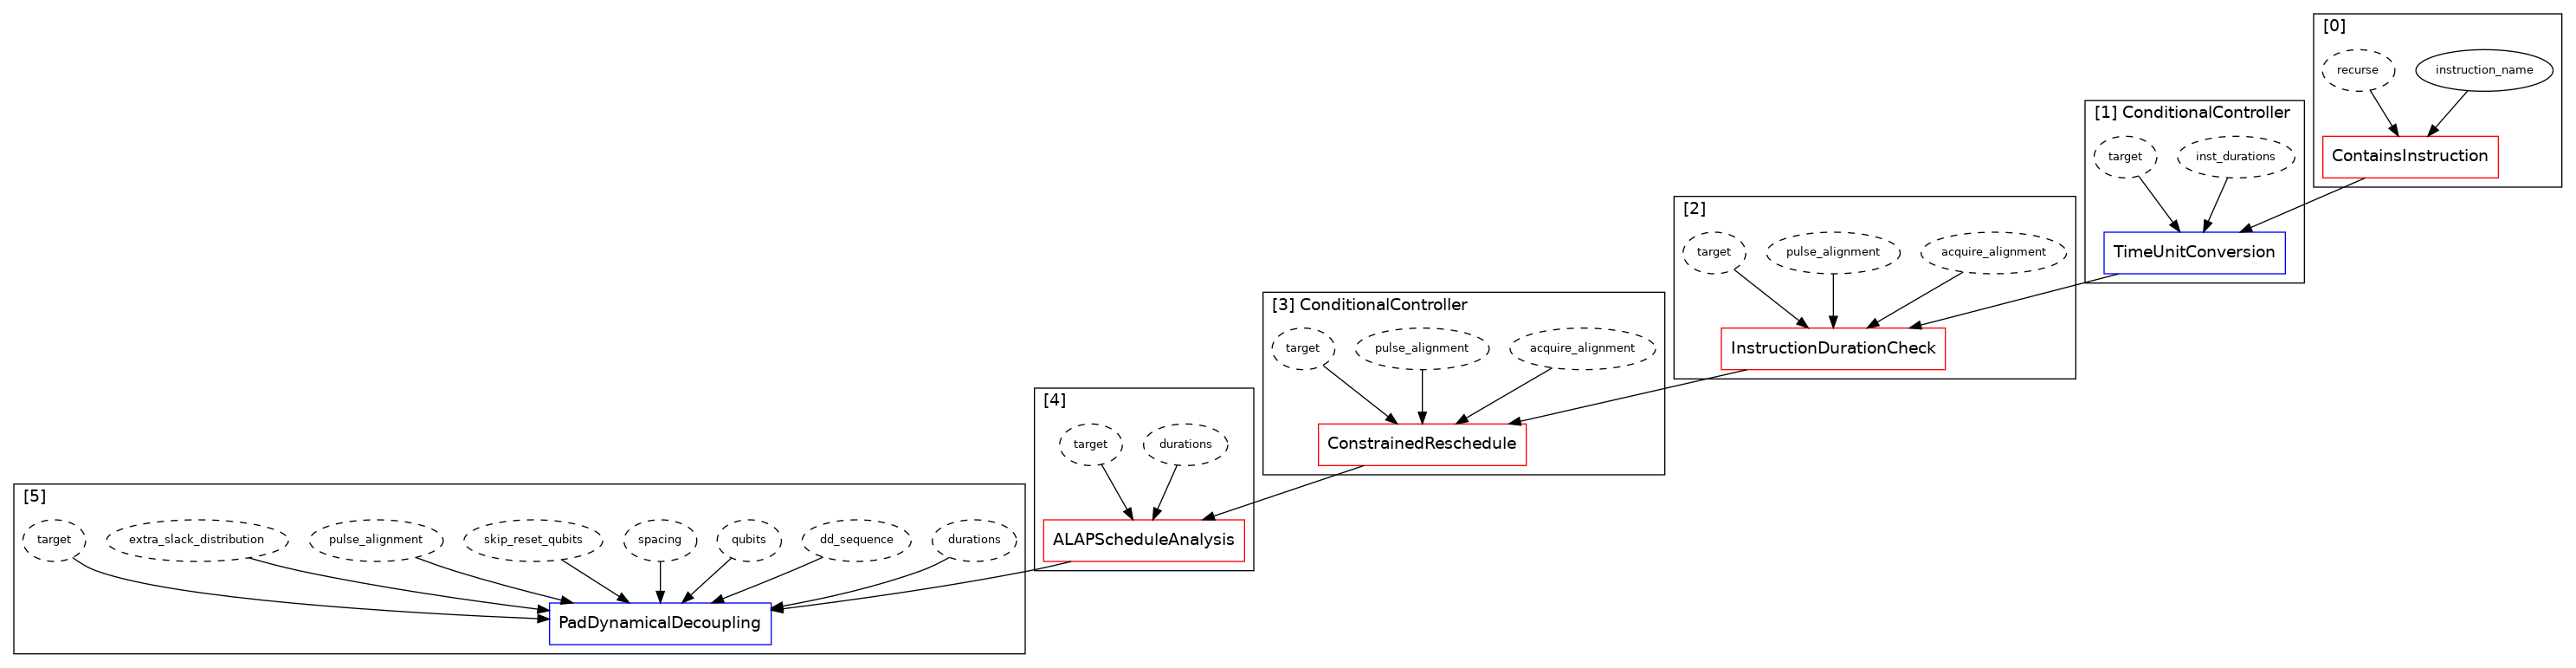

In [12]:
pm_dd.scheduling.draw()

In [8]:
isa_dict["7"].draw(fold=-1)

global phase: 5π/4
          ┌─────────┐┌────┐ ┌───────┐                                                                                                        ┌────┐┌─────────┐ ░                   ┌─┐
q_6 -> 45 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─░───────────────────┤M├
          ├─────────┤├────┤ ├───────┤                                                                                    ┌────┐┌─────────┐ │ └────┘└─────────┘ ░                ┌─┐└╥┘
q_5 -> 46 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────░────────────────┤M├─╫─
          ├─────────┤├────┤ ├───────┤                                                                ┌────┐┌─────────┐ │ └────┘└─────────┘                     ░             ┌─┐└╥┘ ║ 
q_4 -> 55 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────░─────────────┤M├─╫──╫─
          ├─────────┤├────┤ ├───────┤                                            ┌────┐┌─────────┐ │ └────┘└─────────┘                                         ░          ┌─┐└╥┘ ║  ║ 
q_3 -> 65 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────░──────────┤M├─╫──╫──╫─
          ├─────────┤├────┤ ├───────┤                        ┌────┐┌─────────┐ │ └────┘└─────────┘                                                             ░       ┌─┐└╥┘ ║  ║  ║ 
q_2 -> 66 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──────────────────────■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────────────────────────░───────┤M├─╫──╫──╫──╫─
          ├─────────┤├────┤ ├───────┤    ┌────┐┌─────────┐ │ └────┘└─────────┘                                                                                 ░    ┌─┐└╥┘ ║  ║  ║  ║ 
q_1 -> 67 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────────────────────────────────────────────░────┤M├─╫──╫──╫──╫──╫─
          ├─────────┤├────┤┌┴───────┴┐ │ └────┘└─────────┘                                                                                                     ░ ┌─┐└╥┘ ║  ║  ║  ║  ║ 
q_0 -> 68 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤M├─╫──╫──╫──╫──╫──╫─
          └─────────┘└────┘└─────────┘                                                                                                                         ░ └╥┘ ║  ║  ║  ║  ║  ║ 
  meas: 7/════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩══╩═
                                                                                                                                                                  0  1  2  3  4  5  6

In [21]:
isa_dd_dict["7"].draw(idle_wires=True, fold=-1)

global phase: 5π/4
                   ┌────────────────┐                                                                                                                                                                                                                                                                                                                                              
    ancilla_0 -> 0 ┤ Delay(566[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   ├────────────────┤                                                                                                                                                                                                                                                                                                                                              
    ancilla_1 -> 1 ┤ Delay(566[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   ├────────────────┤                                                                                                                                                                                                                                                                                                                                              
    ancilla_2 -> 2 ┤ Delay(566[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   ├────────────────┤                                                                                                                                                                                                                                                                                                                                              
    ancilla_3 -> 3 ┤ Delay(566[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   ├────────────────┤                                                                                                                                                                                                                                                                                                                                              
    ancilla_4 -> 4 ┤ Delay(566[dt]) ├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                   ├────────────────┤                                                                                                                                                                                                                                

In [16]:
# isa_dict["7"]
actual_qubits = isa_dict["7"].layout.final_index_layout()
actual_qubits

[68, 67, 66, 65, 55, 46, 45]

In [17]:
isa_dd_dict["7"].layout.final_index_layout()

[68, 67, 66, 65, 55, 46, 45]

In [18]:
isa_dict["7"].layout

TranspileLayout(initial_layout=Layout({
68: <Qubit register=(7, "q"), index=0>,
67: <Qubit register=(7, "q"), index=1>,
66: <Qubit register=(7, "q"), index=2>,
65: <Qubit register=(7, "q"), index=3>,
55: <Qubit register=(7, "q"), index=4>,
46: <Qubit register=(7, "q"), index=5>,
45: <Qubit register=(7, "q"), index=6>,
0: <Qubit register=(126, "ancilla"), index=0>,
1: <Qubit register=(126, "ancilla"), index=1>,
2: <Qubit register=(126, "ancilla"), index=2>,
3: <Qubit register=(126, "ancilla"), index=3>,
4: <Qubit register=(126, "ancilla"), index=4>,
5: <Qubit register=(126, "ancilla"), index=5>,
6: <Qubit register=(126, "ancilla"), index=6>,
7: <Qubit register=(126, "ancilla"), index=7>,
8: <Qubit register=(126, "ancilla"), index=8>,
9: <Qubit register=(126, "ancilla"), index=9>,
10: <Qubit register=(126, "ancilla"), index=10>,
11: <Qubit register=(126, "ancilla"), index=11>,
12: <Qubit register=(126, "ancilla"), index=12>,
13: <Qubit register=(126, "ancilla"), index=13>,
14: <Qubit reg

In [11]:
isa_dd_dict["7"]._layout

TranspileLayout(initial_layout=Layout({
68: <Qubit register=(7, "q"), index=0>,
67: <Qubit register=(7, "q"), index=1>,
66: <Qubit register=(7, "q"), index=2>,
65: <Qubit register=(7, "q"), index=3>,
55: <Qubit register=(7, "q"), index=4>,
46: <Qubit register=(7, "q"), index=5>,
45: <Qubit register=(7, "q"), index=6>,
0: <Qubit register=(126, "ancilla"), index=0>,
1: <Qubit register=(126, "ancilla"), index=1>,
2: <Qubit register=(126, "ancilla"), index=2>,
3: <Qubit register=(126, "ancilla"), index=3>,
4: <Qubit register=(126, "ancilla"), index=4>,
5: <Qubit register=(126, "ancilla"), index=5>,
6: <Qubit register=(126, "ancilla"), index=6>,
7: <Qubit register=(126, "ancilla"), index=7>,
8: <Qubit register=(126, "ancilla"), index=8>,
9: <Qubit register=(126, "ancilla"), index=9>,
10: <Qubit register=(126, "ancilla"), index=10>,
11: <Qubit register=(126, "ancilla"), index=11>,
12: <Qubit register=(126, "ancilla"), index=12>,
13: <Qubit register=(126, "ancilla"), index=13>,
14: <Qubit reg

In [11]:
## PUBs for noiseless simulation
noiseless_pub_list = [noiseless_estimator_pub(i, isa_dict[f"{i}"]) for i in range(7, 11)]
noiseless_pub_list

[(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d6f6319d0>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZIIIIIIIIIZIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4bfcbc50>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIZIIIIIIZZZIIIIIIIIIZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4c14c510>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIZIIIIIIZZZIIIIIIIIIZIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                coeffs=[1.+0.j])),
 (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4bfc9950>,
  SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZIIIIIIIIIZIIIIIIZZZIIIIIIIIIZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
   

In [12]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()


with Batch(backend=noiseless_backend) as batch:
    noiseless_estimator = AerEstimator()
    noiseless_estimator.options.run_options={"shots":4096}
    noiseless_job = noiseless_estimator.run(noiseless_pub_list)
    noiseless_result = noiseless_job.result()


In [13]:
simulated_est_data = {f"{i+7}":noiseless_result[i].data for i in range(0,4)}
print(simulated_est_data['7'].evs , simulated_est_data['7'].stds)
print(simulated_est_data['8'].evs , simulated_est_data['8'].stds)
print(simulated_est_data['9'].evs , simulated_est_data['9'].stds)
print(simulated_est_data['10'].evs, simulated_est_data['10'].stds)

0.0126953125 0.0
1.0 0.0
0.03173828125 0.0
1.0 0.0


In [14]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":estimator_pub(isa_circuit=isa_dict[f"{i}"], isa_dd_circuit=isa_dd_dict[f"{i}"]) for i in range(7, 11)}
pub_hardware_dict

{'7': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d6f6319d0>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZIIIIIIIIIZIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4bfd6590>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZZZIIIIIIIIIZIIIIIIIIZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j]))],
 '8': [(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4bfcbc50>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIZIIIIIIZZZIIIIIIIIIZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIII'],
                 coeffs=[1.+0.j])),
  (<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x751d4bb9b810>,
   SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIIIIIIIIZIIIIIIZZZIIIIIIIIIZIIIIIIZIIIIIIIIIIIIII

In [16]:
## Simulate on Aer Simulator

noisy_backend = AerSimulator()

noise_model = NoiseModel.from_backend(torino)
noisy_result = {}
for i in range(7, 11):
    with Batch(backend=noisy_backend) as batch:
        noisy_estimator = AerEstimator()
        noiseless_estimator.options.backend_options={"noise_model":noise_model}
        noisy_estimator.options.run_options={"shots":4096}
        noisy_job = noisy_estimator.run(pub_hardware_dict[f"{i}"])
        noisy_result[f"{i}"] = (noisy_job.result()[0].data.evs, noisy_job.result()[0].data.stds, noisy_job.result()[1].data.evs, noisy_job.result()[1].data.stds)



In [17]:
noisy_result

{'7': (array(0.01708984), array(0.), array(0.01660156), array(0.)),
 '8': (array(1.), array(0.), array(1.), array(0.)),
 '9': (array(0.00244141), array(0.), array(-0.01660156), array(0.)),
 '10': (array(1.), array(0.), array(1.), array(0.))}

---
---
---

# Hardware Execution Cell. Do not run unless required

In [ ]:
## Executing experiments with iterations = 3. Total circuit to run = 3*4 = 12
# hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(torino, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 3)}

d47kt1d5mhvc73f83ta0
d47kt20jge3c73e1ql8g
d47kt2i10n3c73ebtggg
d47kt2t5mhvc73f83tcg
d47kt3l5mhvc73f83te0
d47kt455mhvc73f83tf0
d47kt4i10n3c73ebtgl0
d47kt57bjc5s73d4vp00
d47kt5l5mhvc73f83tgg
d47kt5q10n3c73ebtgn0
d47kt6fbjc5s73d4vp20
d47kt6t5mhvc73f83tjg


---
---
---

Above are the job-ids of experiments. Used these to get the Result Objects. 

In [18]:
import pandas as pd
from qiskit_ibm_runtime import QiskitRuntimeService

hardware_job_dict = {'0': {'7': 'd47kt1d5mhvc73f83ta0',
  '8': 'd47kt20jge3c73e1ql8g',
  '9': 'd47kt2i10n3c73ebtggg',
  '10': 'd47kt2t5mhvc73f83tcg'},
 '1': {'7': 'd47kt3l5mhvc73f83te0',
  '8': 'd47kt455mhvc73f83tf0',
  '9': 'd47kt4i10n3c73ebtgl0',
  '10': 'd47kt57bjc5s73d4vp00'},
 '2': {'7': 'd47kt5l5mhvc73f83tgg',
  '8': 'd47kt5q10n3c73ebtgn0',
  '9': 'd47kt6fbjc5s73d4vp20',
  '10': 'd47kt6t5mhvc73f83tjg'}}


In [19]:
hardware_job_dict["0"]["7"]

'd47kt1d5mhvc73f83ta0'

In [20]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-09 12:27:37,267: Loading saved account: qamp-2025


In [21]:
job = service.job("d47kt1d5mhvc73f83ta0")
job.result()[0].metadata['shots']


4096

In [22]:

def store_estimator_data(service, job_dict):
    #           0         1       2        3         4           5         6        7         
    # Index iteration | job_id | Qubit | shots | no_dd_evs | no_dd_std | dd_evs | dd_std |
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "no_dd_evs", "no_dd_std", "dd_evs", "dd_std"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            shots = result[0].metadata["shots"]
            data_list.append(shots)

            data_list.append(result[0].data.evs)

            data_list.append(result[0].data.stds)

            data_list.append(result[1].data.evs)

            data_list.append(result[0].data.stds)
        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [23]:
experiment_results = store_estimator_data(service, hardware_job_dict)

In [24]:
## Save data to .csv

experiment_results.to_csv("GHZ-on-hardware-estimator.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [25]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [26]:

df = pd.read_csv("GHZ-on-hardware-estimator.csv")
df


,iteration,job_id,Qubit,shots,no_dd_evs,no_dd_std,dd_evs,dd_std
0,0,d47kt1d5mhvc73f83ta0,7,4096,0.116211,0.015519,0.104004,0.015519
1,0,d47kt20jge3c73e1ql8g,8,4096,0.709961,0.011004,0.635742,0.011004
2,0,d47kt2i10n3c73ebtggg,9,4096,0.112793,0.015525,0.077148,0.015525
3,0,d47kt2t5mhvc73f83tcg,10,4096,0.641602,0.011985,0.564941,0.011985
4,1,d47kt3l5mhvc73f83te0,7,4096,0.107422,0.015535,0.069824,0.015535
5,1,d47kt455mhvc73f83tf0,8,4096,0.735840,0.010581,0.639160,0.010581
6,1,d47kt4i10n3c73ebtgl0,9,4096,0.112305,0.015526,0.092285,0.015526
7,1,d47kt57bjc5s73d4vp00,10,4096,0.662598,0.011703,0.571777,0.011703
8,2,d47kt5l5mhvc73f83tgg,7,4096,0.120605,0.015511,0.060547,0.015511
9,2,d47kt5q10n3c73ebtgn0,8,4096,0.751953,0.010300,0.662598,0.010300


In [27]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]


In [28]:
qubit_7.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_evs,dd_std
count,3.0,3.0,3.0,3.000000,3.000000,3.000000,3.000000
mean,1.0,7.0,4096.0,0.114746,0.015522,0.078125,0.015522
std,1.0,0.0,0.0,0.006713,0.000012,0.022887,0.000012
min,0.0,7.0,4096.0,0.107422,0.015511,0.060547,0.015511
25%,0.5,7.0,4096.0,0.111816,0.015515,0.065186,0.015515
50%,1.0,7.0,4096.0,0.116211,0.015519,0.069824,0.015519
75%,1.5,7.0,4096.0,0.118408,0.015527,0.086914,0.015527
max,2.0,7.0,4096.0,0.120605,0.015535,0.104004,0.015535


In [29]:
qubit_8.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_evs,dd_std
count,3.0,3.0,3.0,3.000000,3.000000,3.000000,3.000000
mean,1.0,8.0,4096.0,0.732585,0.010628,0.645833,0.010628
std,1.0,0.0,0.0,0.021185,0.000354,0.014619,0.000354
min,0.0,8.0,4096.0,0.709961,0.010300,0.635742,0.010300
25%,0.5,8.0,4096.0,0.722900,0.010440,0.637451,0.010440
50%,1.0,8.0,4096.0,0.735840,0.010581,0.639160,0.010581
75%,1.5,8.0,4096.0,0.743896,0.010792,0.650879,0.010792
max,2.0,8.0,4096.0,0.751953,0.011004,0.662598,0.011004


In [30]:
qubit_9.describe()


,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_evs,dd_std
count,3.0,3.0,3.0,3.000000,3.000000,3.000000,3.000000
mean,1.0,9.0,4096.0,0.105469,0.015537,0.084473,0.015537
std,1.0,0.0,0.0,0.012265,0.000020,0.007580,0.000020
min,0.0,9.0,4096.0,0.091309,0.015525,0.077148,0.015525
25%,0.5,9.0,4096.0,0.101807,0.015526,0.080566,0.015526
50%,1.0,9.0,4096.0,0.112305,0.015526,0.083984,0.015526
75%,1.5,9.0,4096.0,0.112549,0.015543,0.088135,0.015543
max,2.0,9.0,4096.0,0.112793,0.015560,0.092285,0.015560


In [31]:
qubit_10.describe()

,iteration,Qubit,shots,no_dd_evs,no_dd_std,dd_evs,dd_std
count,3.0,3.0,3.0,3.000000,3.000000,3.000000,3.000000
mean,1.0,10.0,4096.0,0.657715,0.011767,0.567546,0.011767
std,1.0,0.0,0.0,0.014311,0.000194,0.003697,0.000194
min,0.0,10.0,4096.0,0.641602,0.011614,0.564941,0.011614
25%,0.5,10.0,4096.0,0.652100,0.011658,0.565430,0.011658
50%,1.0,10.0,4096.0,0.662598,0.011703,0.565918,0.011703
75%,1.5,10.0,4096.0,0.665771,0.011844,0.568848,0.011844
max,2.0,10.0,4096.0,0.668945,0.011985,0.571777,0.011985
